In [ ]:

import pandas as pd

In [19]:
sales = pd.read_csv('../data/raw/sales_train_validation.csv')
calendar = pd.read_csv('../data/raw/calendar.csv')
prices = pd.read_csv('../data/raw/sell_prices.csv')
print("Sales data shape:", sales.shape)
print("Calendar data shape:", calendar.shape)
print("Prices data shape:", prices.shape)

Sales data shape: (30490, 1919)
Calendar data shape: (1969, 14)
Prices data shape: (6841121, 4)


In [20]:
sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [21]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), str(6)
memory usage: 446.4 MB


In [22]:
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          1969 non-null   str  
 1   wm_yr_wk      1969 non-null   int64
 2   weekday       1969 non-null   str  
 3   wday          1969 non-null   int64
 4   month         1969 non-null   int64
 5   year          1969 non-null   int64
 6   d             1969 non-null   str  
 7   event_name_1  162 non-null    str  
 8   event_type_1  162 non-null    str  
 9   event_name_2  5 non-null      str  
 10  event_type_2  5 non-null      str  
 11  snap_CA       1969 non-null   int64
 12  snap_TX       1969 non-null   int64
 13  snap_WI       1969 non-null   int64
dtypes: int64(7), str(7)
memory usage: 215.5 KB


## 📌 Key Insight - Calendar Data

The calendar.csv has missing values in event columns:
- event_name_1 / event_type_1: only 162 out of 1969 days have values
- event_name_2 / event_type_2: only 5 out of 1969 days have values

**This is NOT a data quality issue.** It simply means most days are 
normal days with no special event. Empty = "no event happened that day".

No cleaning action needed for these columns.

In [23]:
prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    str    
 1   item_id     str    
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 208.8 MB


In [24]:
# Group products by category (HOBBIES, FOODS, HOUSEHOLD)
# and calculate total units sold across all years for each category
category_sales = sales.groupby('cat_id')[sales.columns[6:]].sum().sum(axis=1)
category_sales

cat_id
FOODS        45089939
HOBBIES       6124800
HOUSEHOLD    14480670
dtype: int64

## 📌 Key Insight - Category-wise Sales

Total units sold (2011-2016):
- FOODS: 45,089,939 units (74% of total)
- HOUSEHOLD: 14,480,670 units (24% of total)
- HOBBIES: 6,124,800 units (10% of total)

**FOODS is the dominant category**, selling ~3x more than HOUSEHOLD 
and ~7x more than HOBBIES. This makes sense - food items are 
necessities purchased frequently, while hobby items are discretionary 
purchases.

**Business implication:** Inventory planning should prioritize FOODS 
category to avoid stockouts, as it represents the bulk of demand.

In [25]:
# Group by store and calculate total units sold
store_sales = sales.groupby('store_id')[sales.columns[6:]].sum().sum(axis=1)
store_sales


store_id
CA_1     7698216
CA_2     5685475
CA_3    11188180
CA_4     4103676
TX_1     5595292
TX_2     7214384
TX_3     6089330
WI_1     5149062
WI_2     6544012
WI_3     6427782
dtype: int64

## 📌 Key Insight - Store-wise Sales

Top performer: CA_3 with 11.2 million units sold
Lowest performer: CA_4 with 4.1 million units sold

CA_3 sells nearly 3x more than CA_4, despite both being California 
stores. This suggests store-specific factors (size, location, local 
demographics) significantly impact sales volume - not just the state.

**Business implication:** CA_3's success factors should be studied 
and potentially replicated at underperforming stores like CA_4.

In [26]:
# Group by state and calculate total units sold
state_sales = sales.groupby('state_id')[sales.columns[6:]].sum().sum(axis=1)
state_sales

state_id
CA    28675547
TX    18899006
WI    18120856
dtype: int64

## 📌 Key Insight - State-wise Sales

Total units sold by state (2011-2016):
- CA: 28,675,547 units (44%)
- TX: 18,899,006 units (29%)
- WI: 18,120,856 units (27%)

California leads with significantly higher sales, partly due to having 
4 stores vs 3 stores in TX and WI. TX and WI perform similarly to 
each other.

**Note:** A fairer comparison would be average sales per store rather 
than total - CA's lead may partly just reflect having more stores.

# Week 1 - Day 2: Time-based Analysis & Visualizations

## Goal for today:
- Merge sales data with calendar to enable date-based analysis
- Analyze overall sales trends over time (monthly/yearly)
- Analyze category-wise sales trends (do FOODS/HOBBIES/HOUSEHOLD 
  have different seasonal patterns?)
- Analyze holiday/event impact on overall and category-wise sales
- Create visualizations for key findings

In [27]:
# Overall daily totals.
daily_totals = sales[sales.columns[6:]].sum()
daily_totals = daily_totals.reset_index()
daily_totals.columns = ['d', 'total_sales']
daily_totals.head()


,d,total_sales
0,d_1,32631
1,d_2,31749
2,d_3,23783
3,d_4,25412
4,d_5,19146


In [28]:
# Merge daily totals with calendar to get real dates, month, year, and event info

daily_totals = daily_totals.merge(calendar[['d', 'date', 'month', 'year', 'event_name_1', 'event_type_1']], on='d')
daily_totals.head()

,d,total_sales,date,month,year,event_name_1,event_type_1
0,d_1,32631,2011-01-29,1,2011,NaN,NaN
1,d_2,31749,2011-01-30,1,2011,NaN,NaN
2,d_3,23783,2011-01-31,1,2011,NaN,NaN
3,d_4,25412,2011-02-01,2,2011,NaN,NaN
4,d_5,19146,2011-02-02,2,2011,NaN,NaN


In [29]:
daily_totals.shape


(1913, 7)

## 🔧 Data Preparation Note

Merged daily aggregated sales totals with calendar data to enable 
date-based analysis (monthly/yearly trends, holiday impact).

In [30]:
# Total sales by year
yearly_sales = daily_totals.groupby('year')['total_sales'].sum()
yearly_sales

year
2011     8856585
2012    12061837
2013    13135753
2014    13089776
2015    13800811
2016     4750647
Name: total_sales, dtype: int64

## 📌 Key Insight - Yearly Sales Trend

Total sales by year:
- 2011: 8.86M | 2012: 12.06M | 2013: 13.14M | 2014: 13.09M | 2015: 13.80M | 2016: 4.75M

Sales grew steadily 2011→2015, but 2016 shows a sharp drop.

**⚠️ Is this a real drop, or is 2016 just incomplete data?** Let's check.

In [31]:
# Check date range for 2016
daily_totals[daily_totals['year'] == 2016]['date'].agg(['min', 'max', 'count'])

min      2016-01-01
max      2016-04-24
count           115
Name: date, dtype: object

## ✅ Mystery Solved - 2016 is Incomplete

2016 data only covers Jan 1 - Apr 24 (115 days), not a full year.

**The "drop" in 2016 is NOT a real sales decline** — it's because 
we only have ~4 months of data for that year, vs full years for 
2011-2015.

**Correction needed:** For fair year-to-year comparison, we should 
either exclude 2016 or compare using average daily sales instead 
of yearly totals.

In [32]:
# Average daily sales by year (fairer comparison)
avg_daily_sales = daily_totals.groupby('year')['total_sales'].mean()
avg_daily_sales

year
2011    26280.667656
2012    32955.838798
2013    35988.364384
2014    35862.400000
2015    37810.441096
2016    41309.973913
Name: total_sales, dtype: float64

## 📌 Key Insight - Yearly Sales Growth (Corrected)

Average daily sales by year:
- 2011: 26,281 | 2012: 32,956 | 2013: 35,988
- 2014: 35,862 | 2015: 37,810 | 2016: 41,310

**Sales have grown consistently every year — up ~57% from 2011 to 2016.**
2016 is actually the BEST performing year on a per-day basis.

In [33]:
# Average daily sales by month (across all years)
monthly_sales = daily_totals.groupby('month')['total_sales'].mean()
monthly_sales

month
1     33832.348101
2     34644.641176
3     34339.838710
4     34258.683908
5     32503.851613
6     35001.413333
7     35122.419355
8     35946.645161
9     35479.260000
10    34713.477419
11    33290.826667
12    32980.464516
Name: total_sales, dtype: float64

## 📌 Key Insight - Monthly Sales Pattern

Avg daily sales by month (1=Jan, 12=Dec):
- Highest: August (35,947) 
- Lowest: May (32,504)
- Difference: only ~10% between best and worst month

**Surprising finding:** No dramatic December holiday spike — sales 
are relatively stable year-round. This is likely because FOODS 
(74% of all sales) are purchased consistently every month, 
dampening seasonal effects seen in other retail categories.

In [34]:
# Compare sales on event days vs normal days
event_sales = daily_totals.groupby(daily_totals['event_name_1'].isna())['total_sales'].mean()
event_sales.index = ['Event Day', 'Normal Day']
event_sales

Event Day     32655.149351
Normal Day    34489.207504
Name: total_sales, dtype: float64

## 📌 Key Insight - Holiday/Event Impact

Average daily sales:
- Event Days: 32,655
- Normal Days: 34,489

**Unexpected finding:** Sales are ~5% LOWER on event/holiday days 
vs normal days. This suggests customers shop BEFORE holidays 
(stocking up), not on the actual holiday. Stores may also have 
reduced hours on holidays.

**Business implication:** Inventory should be stocked UP in the 
days BEFORE major events, not on the event day itself.

## 📊 Visualizations - Week 1 EDA Charts

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for all charts
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

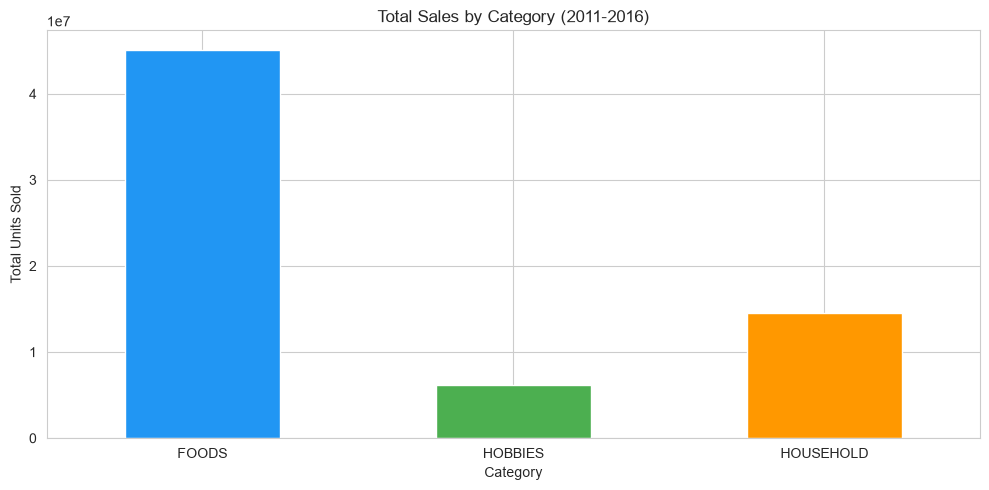

In [36]:
# Chart 1: Category-wise total sales
category_sales.plot(kind='bar', color=['#2196F3', '#4CAF50', '#FF9800'])
plt.title('Total Sales by Category (2011-2016)')
plt.xlabel('Category')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 📊 Chart 1: Total Sales by Category (2011-2016)

FOODS clearly dominates — selling ~3x more than HOUSEHOLD 
and ~7x more than HOBBIES. Visual confirms our earlier finding.

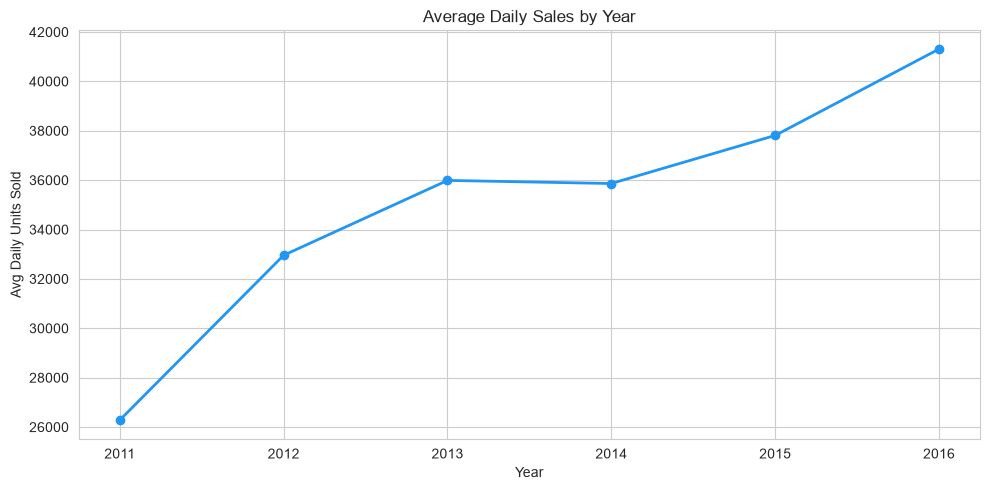

In [37]:
# Chart 2: Yearly average daily sales trend
avg_daily_sales.plot(kind='line', marker='o', color='#2196F3', linewidth=2)
plt.title('Average Daily Sales by Year')
plt.xlabel('Year')
plt.ylabel('Avg Daily Units Sold')
plt.tight_layout()
plt.show()

## 📊 Chart 2: Average Daily Sales by Year

Clear upward trend from 2011 to 2016 (+57% growth overall).
Minor plateau in 2013-2014, but growth resumes strongly after.
This consistent growth trend will be a key input for our 
Prophet forecasting model in Week 3.

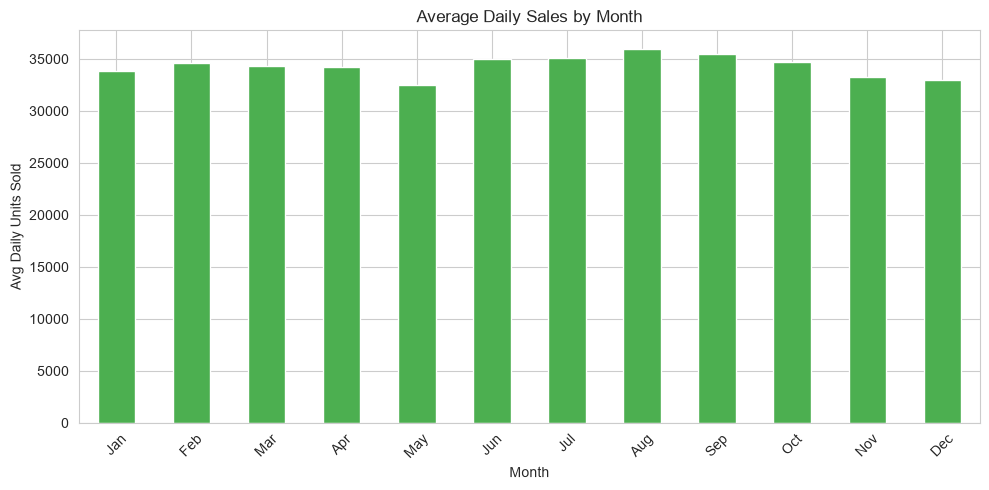

In [38]:
# Chart 3: Average daily sales by month
monthly_sales.plot(kind='bar', color='#4CAF50')
plt.title('Average Daily Sales by Month')
plt.xlabel('Month')
plt.ylabel('Avg Daily Units Sold')
plt.xticks(ticks=range(12), 
           labels=['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec'], 
           rotation=45)
plt.tight_layout()
plt.show()

## 📊 Chart 3: Average Daily Sales by Month

Sales are remarkably stable across all months (32K-36K range).
- Peak month: August (35,947)
- Lowest month: May (32,504)
- Only ~10% difference between best and worst month
- No December holiday spike — consistent with FOODS dominance 
  (groceries

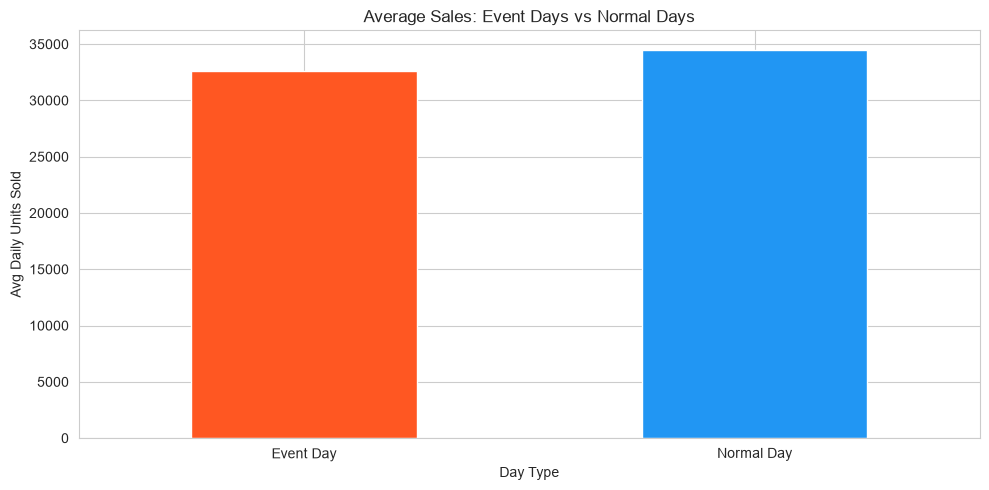

In [39]:
# Chart 4: Event day vs Normal day sales comparison
event_sales.plot(kind='bar', color=['#FF5722', '#2196F3'])
plt.title('Average Sales: Event Days vs Normal Days')
plt.xlabel('Day Type')
plt.ylabel('Avg Daily Units Sold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 📊 Chart 4: Event Days vs Normal Days

Normal days (blue) outsell event days (orange) by ~5%.
Sales actually DIP slightly on holidays — customers likely 
stock up BEFORE events, not on the day itself.